In [2]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Config
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [9]:
RAW_PATH = "../data/raw/loan.csv"
try:
    df_raw = pd.read_csv(RAW_PATH, nrows=50000, low_memory=False)
    print("--- PROFIL RAW DATA ---")
    print(f"Total Baris (Sampled): {df_raw.shape[0]:,}")
    print(f"Total Kolom: {df_raw.shape[1]}")

    print(df_raw.head(5))
except FileNotFoundError:
    print(f"ERROR: File tidak ditemukan di {RAW_PATH}.")

--- PROFIL RAW DATA ---
Total Baris (Sampled): 50,000
Total Kolom: 145
   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500             2500   36 months   
1 NaN        NaN      30000        30000            30000   60 months   
2 NaN        NaN       5000         5000             5000   36 months   
3 NaN        NaN       4000         4000             4000   36 months   
4 NaN        NaN      30000        30000            30000   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...                            NaN   
4     16.14       731.78     C        C4  ...                            NaN   

  hardshi

### 1. Analisis Missing Values
Step 1 adalah melihat missing value di data kita. Kolom dengan persentase *missing value* di atas 50% biasanya akan kita buang (drop) karena terlalu banyak informasi yang hilang untuk bisa diimputasi secara akurat.

Terdapat 61 kolom yang memiliki missing value.
Terdapat 43 kolom dengan missing value di atas 50%.


C:\Users\axels\AppData\Local\Temp\ipykernel_24468\1312747578.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_missing.head(20).values, y=high_missing.head(20).index, palette="viridis")


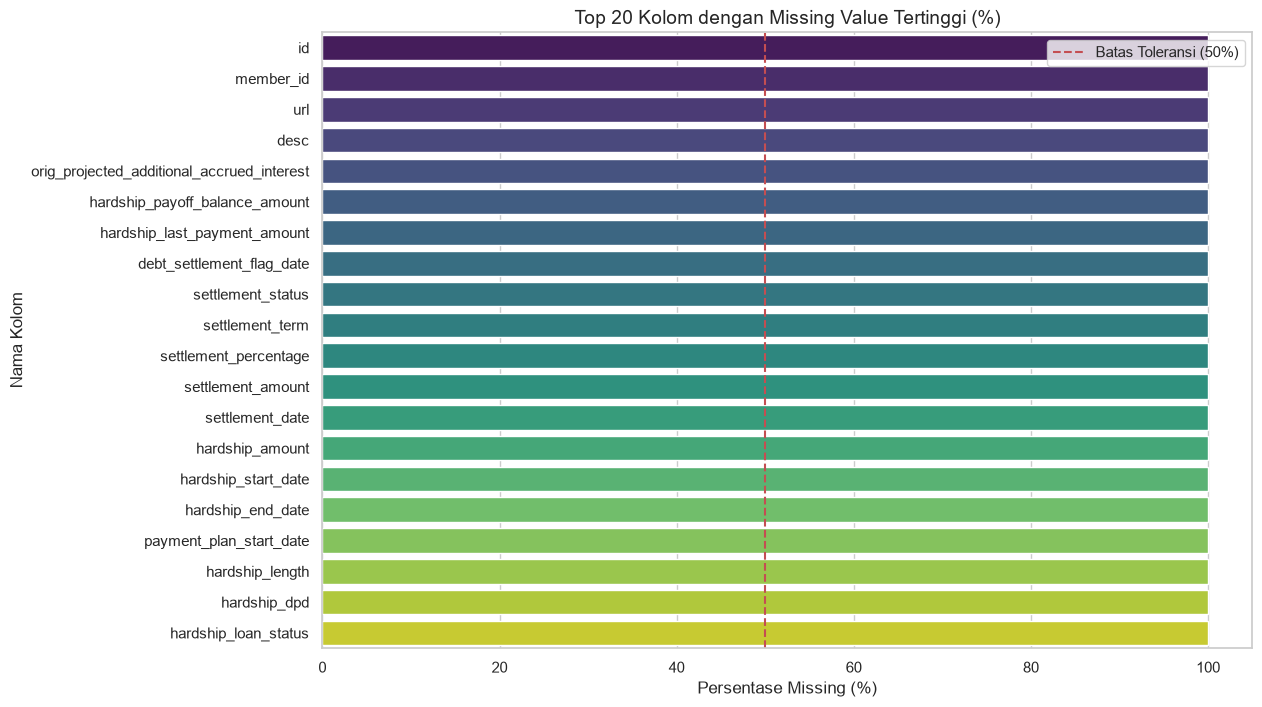

Insight: Banyak kolom terkait 'joint account' (misal: sec_app_fico_range_low) atau metrik sekunder yang kosong hingga 100%. Kolom-kolom ini mutlak harus dibuang saat proses ETL.


In [10]:
# Menghitung persentase missing value per kolom
missing_percentages = (df_raw.isnull().sum() / len(df_raw)) * 100
high_missing = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print(f"Terdapat {len(high_missing)} kolom yang memiliki missing value.")
print(f"Terdapat {len(high_missing[high_missing > 50])} kolom dengan missing value di atas 50%.")

# Visualisasi Top 20 kolom dengan missing value tertinggi
plt.figure(figsize=(12, 8))
sns.barplot(x=high_missing.head(20).values, y=high_missing.head(20).index, palette="viridis")
plt.title("Top 20 Kolom dengan Missing Value Tertinggi (%)", fontsize=14)
plt.xlabel("Persentase Missing (%)", fontsize=12)
plt.ylabel("Nama Kolom", fontsize=12)
plt.axvline(x=50, color='r', linestyle='--', label='Batas Toleransi (50%)')
plt.legend()
plt.show()

print("Insight: Banyak kolom terkait 'joint account' (misal: sec_app_fico_range_low) atau metrik " \
"sekunder yang kosong hingga 100%. Kolom-kolom ini mutlak harus dibuang saat proses ETL.")

### 2. Diagnosis Target Variable (`loan_status`)
Sebelum kita prediksi gagal bayar, kita harus lihat status asli pinjaman di dalam data operasional.

C:\Users\axels\AppData\Local\Temp\ipykernel_24468\176865267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_raw, y='loan_status', order=df_raw['loan_status'].value_counts().index, palette="magma")


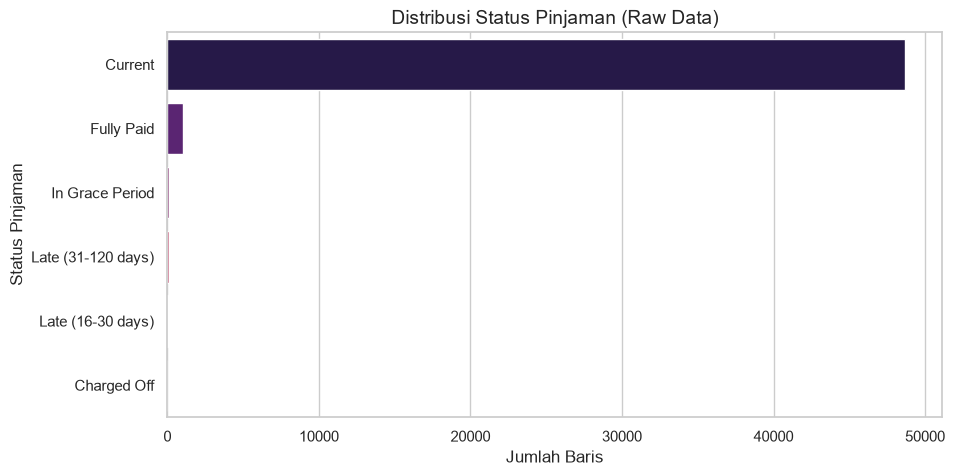


--- ANALISIS KEBOCORAN TARGET ---
Insight 1: Status 'Current' mendominasi data. Ini adalah pinjaman yang (masih ongoing). Kita tidak tahu apakah ke depannya mereka akan lancar atau macet.
Tindakan: Baris dengan status 'Current' HARUS DIBUANG. Kita hanya mengambil status yang sudah mencapai akhir siklus (Fully Paid, Charged Off, Default).


In [11]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_raw, y='loan_status', order=df_raw['loan_status'].value_counts().index, palette="magma")
plt.title("Distribusi Status Pinjaman (Raw Data)", fontsize=14)
plt.xlabel("Jumlah Baris", fontsize=12)
plt.ylabel("Status Pinjaman", fontsize=12)
plt.show()

print("\n--- ANALISIS KEBOCORAN TARGET ---")
print("Insight 1: Status 'Current' mendominasi data. Ini adalah pinjaman yang (masih ongoing). " \
"Kita tidak tahu apakah ke depannya mereka akan lancar atau macet.")
print("Tindakan: Baris dengan status 'Current' HARUS DIBUANG. Kita hanya mengambil status " \
"yang sudah mencapai akhir siklus (Fully Paid, Charged Off, Default).")

### 3. Univariate Analysis (Fitur Numerik Utama)
kita lihat distribusi beberapa kolom numerik yang kelihatannya aman (tidak banyak missing value) sebelum dibersihkan, seperti jumlah pinjaman (`loan_amnt`) dan suku bunga (`int_rate`).

C:\Users\axels\AppData\Local\Temp\ipykernel_24468\3897255940.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_raw['int_rate_num'] = df_raw['int_rate']


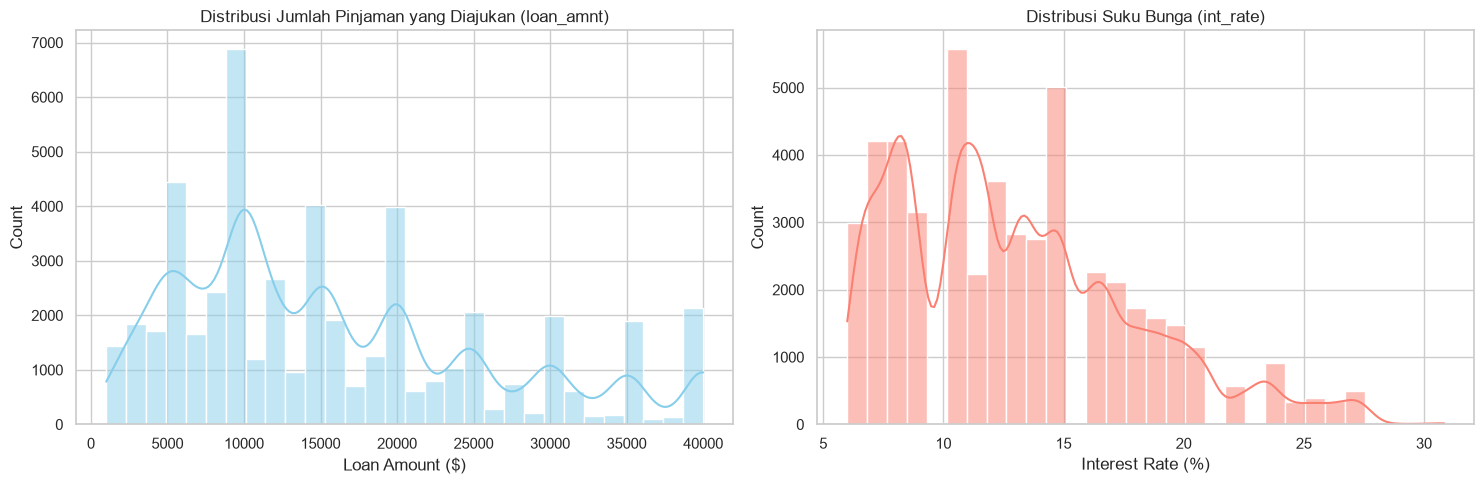

Insight: Jumlah pinjaman cenderung memuncak pada angka-angka bulat (seperti 10.000, 15.000, 20.000). Suku bunga berdistribusi condong ke kanan (right-skewed).


In [12]:
# Mengekstrak suku bunga (int_rate) jika formatnya masih string dengan tanda '%'
if df_raw['int_rate'].dtype == 'O':
    df_raw['int_rate_num'] = df_raw['int_rate'].str.replace('%', '').astype(float)
else:
    df_raw['int_rate_num'] = df_raw['int_rate']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loan Amount
sns.histplot(df_raw['loan_amnt'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Jumlah Pinjaman yang Diajukan (loan_amnt)')
axes[0].set_xlabel('Loan Amount ($)')

# Plot Interest Rate
sns.histplot(df_raw['int_rate_num'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Suku Bunga (int_rate)')
axes[1].set_xlabel('Interest Rate (%)')

plt.tight_layout()
plt.show()

print("Insight: Jumlah pinjaman cenderung memuncak pada angka-angka bulat (seperti 10.000, 15.000, 20.000). " \
"Suku bunga berdistribusi condong ke kanan (right-skewed).")

### 4. Multivariate Analysis (Mendeteksi Data Leakage)
Di dataset perbankan raw, terdapat kolom-kolom *Post-Origination* (Data yang tercatat setelah pinjaman berjalan), seperti total pokok yang sudah dibayar (`total_rec_prncp`). 
sekarang kita lihat korelasinya dengan status gagal bayar (jika kita paksakan masuk ke model).

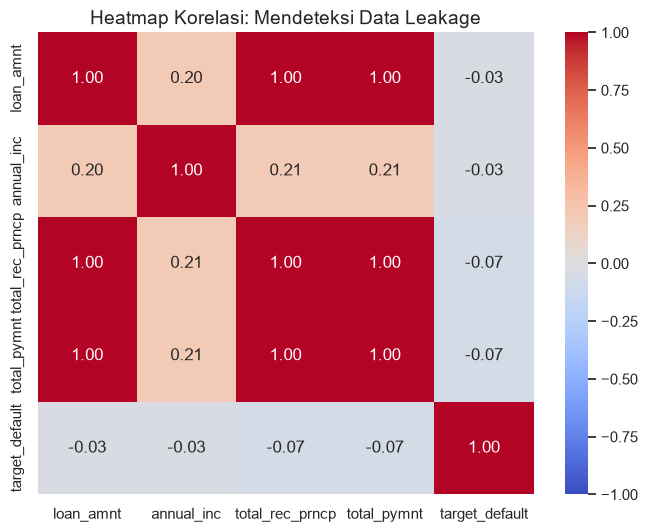

--- BAHAYA DATA LEAKAGE ---
Perhatikan korelasi negatif yang sangat kuat antara 'target_default' dengan 'total_rec_prncp' (Total pokok dibayar).
Jika fitur ini dimasukkan ke dalam model ML, model akan 'menyontek'. Model akan tahu: 'Oh, orang ini pokok pinjamannya belum lunas, pasti dia gagal bayar!'.
Tindakan: Kolom post-origination seperti ini mutlak tidak boleh dimasukkan ke parameter `usecols` di pipeline ETL kita.


In [13]:
# Kita buat target tiruan khusus untuk simulasi ini (1=Macet, 0=Lancar) dari data yang bukan 'Current'
df_sim = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_sim['target_default'] = np.where(df_sim['loan_status'] == 'Fully Paid', 0, 1)

# Pilih beberapa fitur pre-origination (aman) vs post-origination (bocor)
cols_to_check = ['loan_amnt', 'annual_inc', 'total_rec_prncp', 'total_pymnt', 'target_default']

plt.figure(figsize=(8, 6))
corr_leak = df_sim[cols_to_check].corr()
sns.heatmap(corr_leak, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Heatmap Korelasi: Mendeteksi Data Leakage", fontsize=14)
plt.show()

print("--- BAHAYA DATA LEAKAGE ---")
print("Perhatikan korelasi negatif yang sangat kuat antara 'target_default' dengan "
"'total_rec_prncp' (Total pokok dibayar).")
print("Jika fitur ini dimasukkan ke dalam model ML, model akan 'menyontek'. " \
"Model akan tahu: 'Oh, orang ini pokok pinjamannya belum lunas, pasti dia gagal bayar!'.")
print("Tindakan: Kolom post-origination seperti ini mutlak tidak boleh dimasukkan " \
"ke parameter `usecols` di pipeline ETL kita.")